# Regional extent of Structure Exposure Networks

This notebook applies the SEN definition from Notebook 04 to a continuous 117.5-km² corridor along the southern Santa Monica Mountains, extending from Santa Monica and Pacific Palisades to Silver Lake and Echo Park. It identifies building networks whose geometric connectivity spans the CAL FIRE WUI Interface class. The product is a regional structural-connectivity screen: no fire arrival, ignition or damage observations are used, and the mapped components should not be interpreted as predicted fire perimeters.

**Manuscript link:** Results, *Regional extent of potential structure-to-structure spread*; Main Figure 5. Threshold and corridor-definition sensitivity belong in `extended_data/ED05_sen_sensitivity.ipynb`.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.analysis.regional_sen import (
    audit_corridor_inputs, build_regional_sen,
    regional_category_summary, regional_size_profile,
)
from src.analysis.sen import pooled_single_emitter_threshold
from src.viz.regional_sen import plot_regional_sen

RESULTS = PACKAGE_ROOT / 'results'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
FIGURES = PACKAGE_ROOT / 'figures' / 'main'
for directory in [RESULTS, SOURCE_DATA, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## Tiled scene reconstruction

The high-compute reconstruction was divided into 2.5-km cores with 250-m halos. Each tile used LARIAC 6 buildings and countywide terrain to construct meshes and evaluate visible building pairs within 100 m. For each ordered pair, all visible emitter patches were aggregated and area-averaged over the core-owned receiver's sampled surface; the larger directional contribution defined the undirected single-emitter bond. Halo overlap protected tile seams and global LARIAC identifiers reconciled duplicate buildings and bonds. Notebook 05 begins from those frozen building- and pair-level products rather than rerunning mesh and line-of-sight simulation.

In [2]:
input_audit = audit_corridor_inputs(PROJECT_ROOT)
if not input_audit.tiles_complete.eq(input_audit.tiles_total).all():
    raise RuntimeError('Regional tile reconstruction is incomplete')
input_audit.to_csv(RESULTS / 'regional_sen_input_audit.csv', index=False)
display(input_audit.round(3))

,corridor,corridor_area_km2,tiles_total,tiles_complete,buildings,candidate_building_pairs,maximum_pair_distance_m,tile_core_m,tile_halo_m
0,Santa Monica Mountains–Silver Lake,117.51,36,36,115111,1135658,100.0,2500.0,250.0


## Regional SEN construction

The pooled single-emitter coupling associated with an absolute fitted $P(\mathrm{destroyed})=0.50$ was used unchanged from Notebook 04. Components were formed over the complete corridor after tile merging, allowing SENs to cross computational tile boundaries. An Interface-spanning SEN contained at least one building whose centroid fell within the CAL FIRE Interface class and at least one building outside that class.

In [3]:
_, threshold_table = pooled_single_emitter_threshold(PROJECT_ROOT / 'data')
F_IJ_THRESHOLD = float(threshold_table.F_ij_threshold.iloc[0])
regional = build_regional_sen(PROJECT_ROOT, F_IJ_THRESHOLD)
regional_summary = regional['summary']
components = regional['components']
size_profile = regional_size_profile(components)
category_summary = regional_category_summary(regional['buildings'])

regional_summary.to_csv(RESULTS / 'regional_sen_summary.csv', index=False)
components.to_csv(RESULTS / 'regional_sen_components.csv', index=False)
size_profile.to_csv(RESULTS / 'regional_sen_size_profile.csv', index=False)
category_summary.to_csv(RESULTS / 'regional_sen_category_summary.csv', index=False)
regional['buildings'][[
    'LARIAC_BLD_ID', 'height', 'sen_id', 'component_size', 'wui_class',
    'spans_interface_class', 'network_category', 'geometry'
]].to_parquet(SOURCE_DATA / 'fig5_regional_sen_map_source.parquet', index=False)
size_profile.to_csv(SOURCE_DATA / 'fig5d_regional_size_profile_source.csv', index=False)
display(regional_summary.T.rename(columns={0: 'value'}))
display(category_summary.round(4))

,value
corridor,Santa Monica Mountains–Silver Lake
screen_buffer_m,NaN
F_ij_threshold,0.026503
P_destroyed_equivalent,0.5
buildings,115111
candidate_pairs,1135658
active_bonds,175749
SENs,10130
connected_SENs,2764
connected_buildings,107745


,network_category,buildings,building_share
0,Isolated,7366,0.0640
1,Other connected SEN,46688,0.4056
2,Interface-spanning SEN,61057,0.5304


## Largest Interface-spanning networks

Planar span is the diagonal of each component's building-centroid bounding box. It describes geographic footprint within the screened corridor, not a modeled direction or path of fire spread.

In [4]:
largest_spanning = (components[components.spans_interface_class]
                    .sort_values('component_size', ascending=False)
                    .head(20)[[
                        'component_id', 'component_size',
                        'interface_buildings', 'other_buildings',
                        'planar_span_km', 'mean_bond_ssd_ft',
                        'near_screen_edge',
                    ]])
largest_spanning.to_csv(RESULTS / 'regional_sen_largest_spanning.csv', index=False)
display(largest_spanning.round(2))

,component_id,component_size,interface_buildings,other_buildings,planar_span_km,mean_bond_ssd_ft,near_screen_edge
2130,2130,9619,2235,7384,5.83,29.78,True
2097,2097,8235,1413,6822,5.98,32.24,True
2056,2056,3406,1141,2265,2.97,31.96,True
2118,2118,3138,789,2349,2.63,28.64,True
4220,4220,1977,78,1899,2.12,30.88,True
8361,8361,1950,5,1945,2.17,26.97,True
4789,4789,1806,619,1187,1.81,29.04,False
8225,8225,1589,67,1522,2.82,31.85,True
6096,6096,1563,1179,384,1.49,24.72,False
8358,8358,1354,990,364,1.90,27.69,False


## Main Figure 5

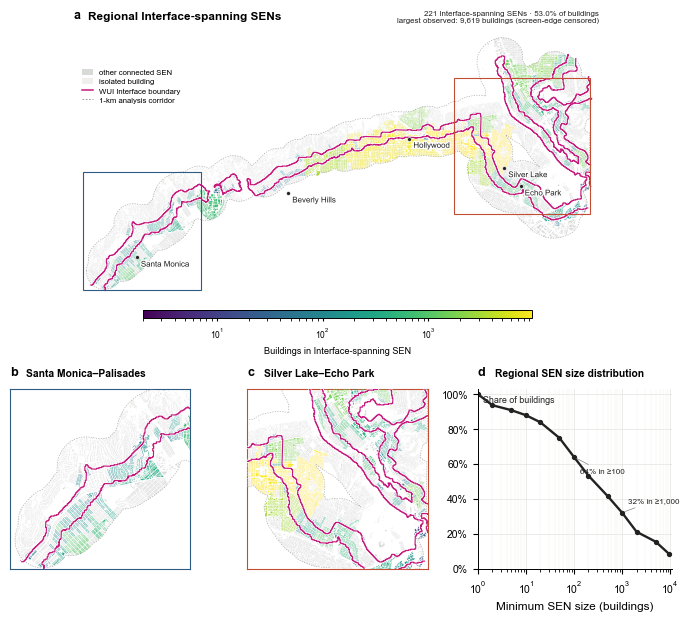

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig5_regional_sen_extent.png


In [5]:
fig = plot_regional_sen(
    regional, size_profile, category_summary,
    project_root=PROJECT_ROOT, output_dir=FIGURES,
)
plt.show()
print('saved', FIGURES / 'Fig5_regional_sen_extent.png')